In [1]:
!pip install statsmodels

In [2]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
import torch
from sklearn.preprocessing import MinMaxScaler
import datetime



In [5]:
data = pd.read_csv('C:/TARUN/DOCUMENT/PROJECT/ADA PROJECT/air_quality_health_dataset.csv')

In [6]:
data

,date,region,AQI,PM2.5,NO2,SO2,CO,O3,temperature,humidity
0,01-01-2020,East,109.934283,31.382887,47.654022,25.874070,0.956973,32.574682,37.555663,20.542799
1,02-01-2020,Central,97.234714,47.094225,50.734127,10.605095,0.990203,23.749138,24.900342,27.308785
2,03-01-2020,East,112.953771,53.795917,44.986899,18.361025,1.019288,35.530851,23.437165,80.055977
3,04-01-2020,West,130.460597,88.315315,20.575023,19.791700,1.284058,25.277106,22.388200,25.929988
4,05-01-2020,South,95.316933,68.348297,38.445776,20.079543,0.775835,35.996440,26.881835,34.946343
...,...,...,...,...,...,...,...,...,...,...
2995,16-03-2020,West,101.549610,62.572040,28.188065,15.451740,1.295485,26.473666,30.823665,39.543222
2996,17-03-2020,Central,105.155051,77.289722,39.271776,26.185755,0.765007,41.684453,28.343987,21.611366
2997,18-03-2020,East,75.164788,41.738943,48.380141,26.561040,1.235577,39.295269,26.050318,80.183686
2998,19-03-2020,Central,106.683528,67.019256,38.993041,15.579454,0.655209,31.667658,26.028273,46.396429


In [7]:
data.shape

(3000, 10)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3000 non-null   str    
 1   region       3000 non-null   str    
 2   AQI          3000 non-null   float64
 3   PM2.5        3000 non-null   float64
 4   NO2          3000 non-null   float64
 5   SO2          3000 non-null   float64
 6   CO           3000 non-null   float64
 7   O3           3000 non-null   float64
 8   temperature  3000 non-null   float64
 9   humidity     3000 non-null   float64
dtypes: float64(8), str(2)
memory usage: 278.4 KB


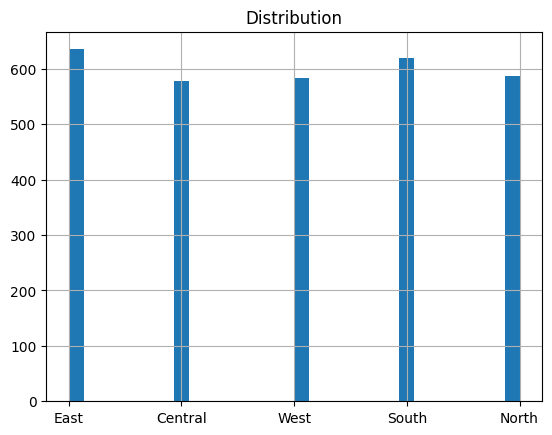

In [9]:
data['region'].hist(bins=30)
plt.title("Distribution")
plt.show()


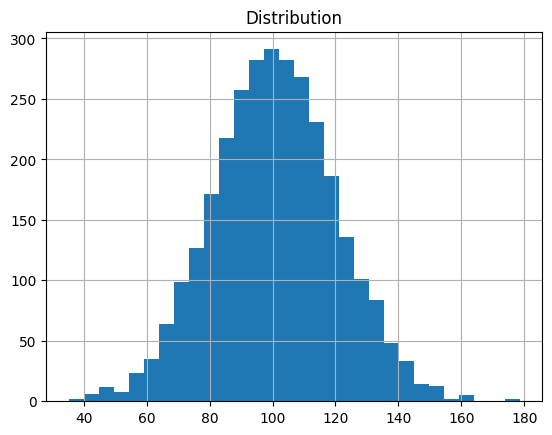

In [10]:
data['AQI'].hist(bins=30)
plt.title("Distribution")
plt.show()


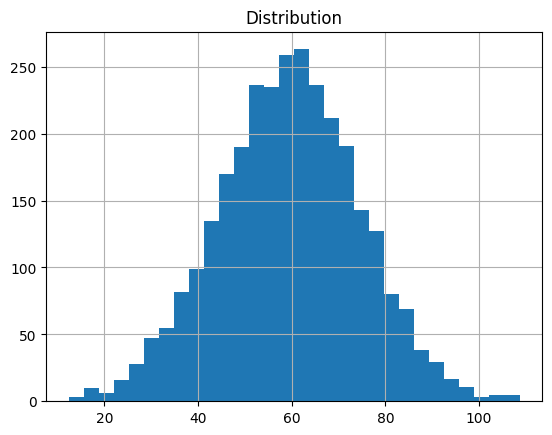

In [11]:
data['PM2.5'].hist(bins=30)
plt.title("Distribution")
plt.show()


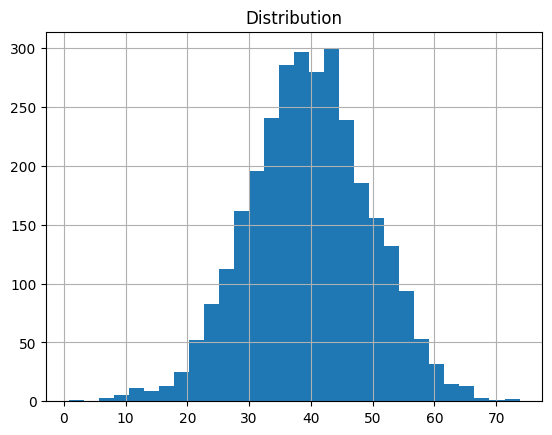

In [12]:
data['NO2'].hist(bins=30)
plt.title("Distribution")
plt.show()


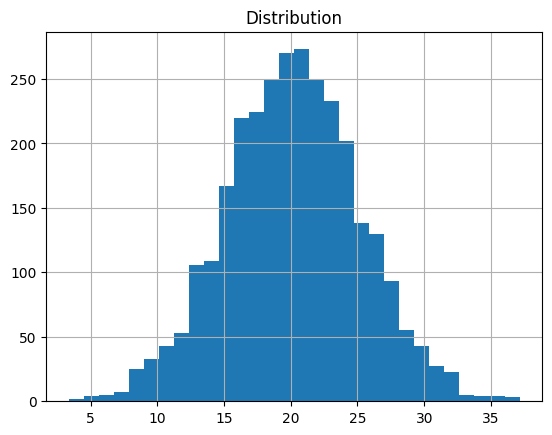

In [13]:
data['SO2'].hist(bins=30)
plt.title("Distribution")
plt.show()


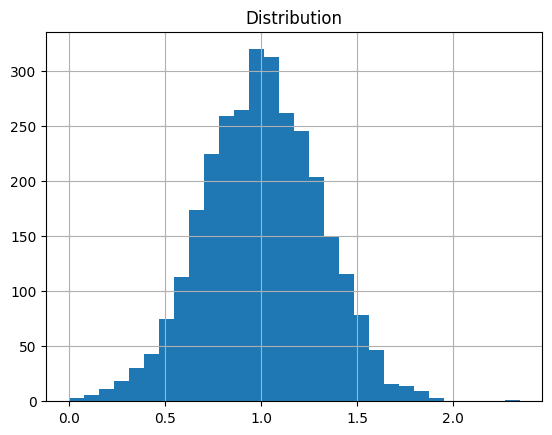

In [14]:
data['CO'].hist(bins=30)
plt.title("Distribution")
plt.show()


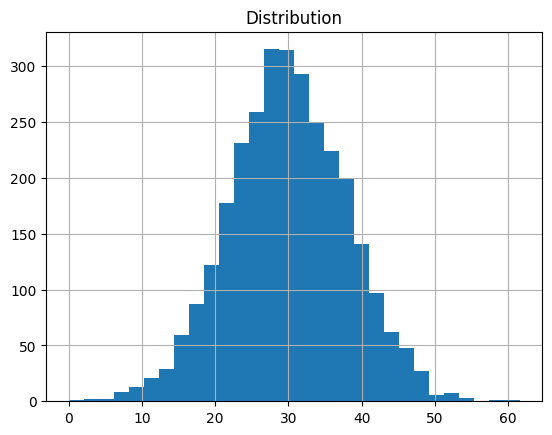

In [15]:
data['O3'].hist(bins=30)
plt.title("Distribution")
plt.show()


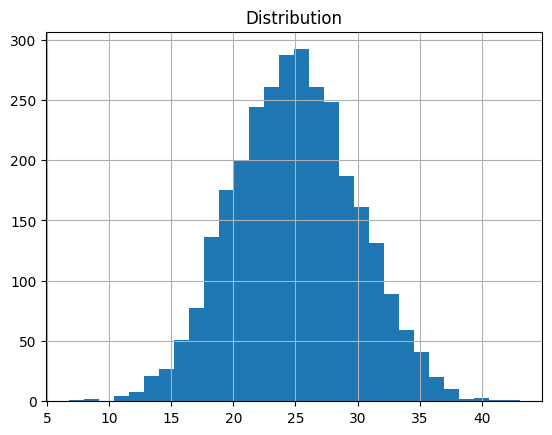

In [16]:
data['temperature'].hist(bins=30)
plt.title("Distribution")
plt.show()


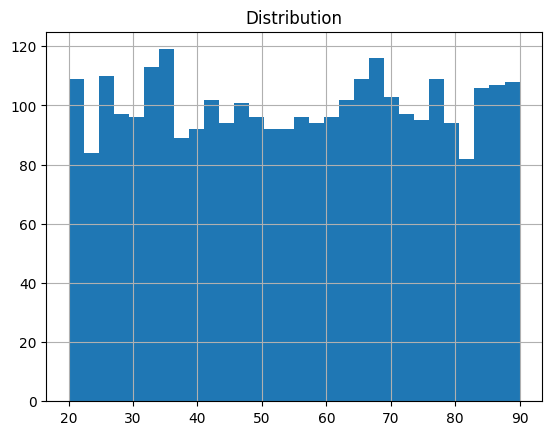

In [17]:
data['humidity'].hist(bins=30)
plt.title("Distribution")
plt.show()


In [18]:
print("\nMissing Values:")#For checking missing values we use this code
print(data.isnull().sum())



Missing Values:
date           0
region         0
AQI            0
PM2.5          0
NO2            0
SO2            0
CO             0
O3             0
temperature    0
humidity       0
dtype: int64


In [19]:
# Outliers 

In [20]:
Q1 = data['AQI'].quantile(0.25)
Q3 = data['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = data[(data['AQI'] < lower) | (data['AQI'] > upper)]


In [21]:
print("Column: AQI")
print("Q1 (25%):", Q1)
print("Q3 (75%):", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)

Column: AQI
Q1 (25%): 87.44917716249999
Q3 (75%): 113.4718177
IQR: 26.02264053750001
Lower Limit: 48.41521635624998
Upper Limit: 152.50577850625


In [22]:
col = "AQI"

Q1 = data['AQI'].quantile(0.25)
Q3 = data['AQI'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
data = data[(data['AQI'] >= lower) & (data['AQI'] <= upper)]

print("Original rows:", len(data))
print("Rows after removing outliers:", len(data))


Original rows: 2971
Rows after removing outliers: 2971


In [23]:
# HEAT MAP WITH RESPECT TO AQI

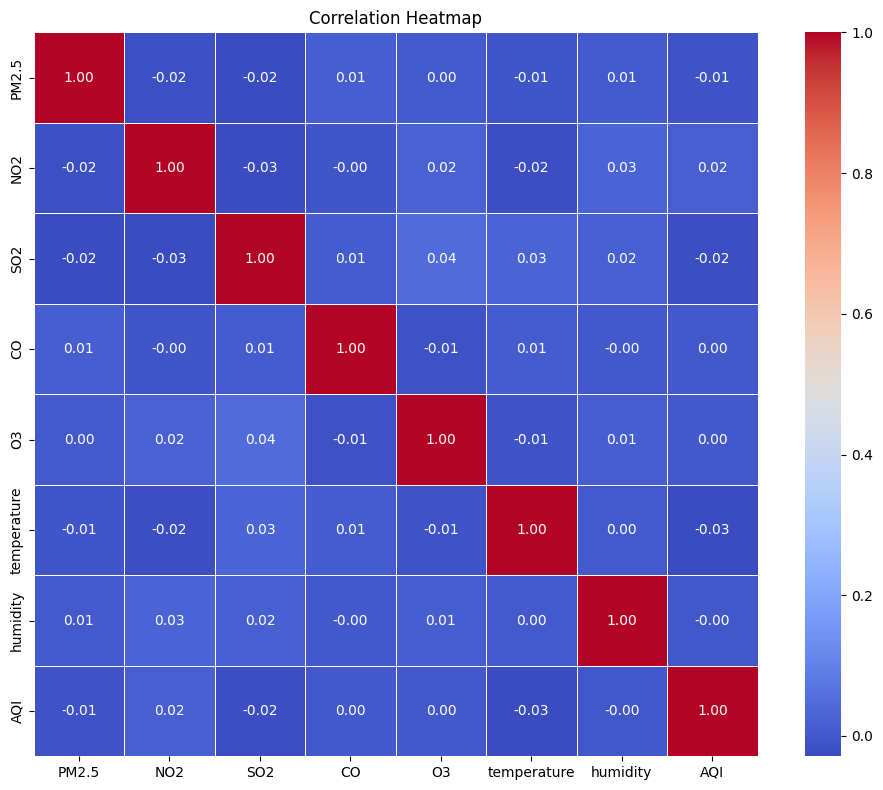

Columns to DROP: []

Remaining columns: ['date', 'region', 'AQI', 'PM2.5', 'NO2', 'SO2', 'CO', 'O3', 'temperature', 'humidity']


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Select numeric columns only
numeric_cols = ['PM2.5', 'NO2', 'SO2', 'CO', 'O3', 'temperature', 'humidity', 'AQI']
df_corr = data[numeric_cols].corr()

# 2. Plot Heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_corr,
    annot=True,               # show numbers
    fmt=".2f",                # 2 decimal places
    cmap="coolwarm",          # blue → red
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()
corr_matrix = data[numeric_cols].corr().abs()

# Upper triangle matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]

print("Columns to DROP:", to_drop)

data_cleaned = data.drop(columns=to_drop)
print("\nRemaining columns:", data_cleaned.columns.tolist())


In [25]:
#ADF Test Code (Stationarity Check)

In [26]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd

# ADF TEST FOR EACH NUMERIC COLUMN
def check_stationarity(df):
    print("\n===== ADF Stationarity Results =====\n")

    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        result = adfuller(df[col].dropna())

        p_value = result[1]
        is_stationary = "YES" if p_value < 0.05 else "NO"

        print(f"Column: {col:15}  |  p-value = {p_value:.4f}  |  Stationary: {is_stationary}")

# Run test
check_stationarity(data)



===== ADF Stationarity Results =====

Column: AQI              |  p-value = 0.0000  |  Stationary: YES
Column: PM2.5            |  p-value = 0.0000  |  Stationary: YES
Column: NO2              |  p-value = 0.0000  |  Stationary: YES
Column: SO2              |  p-value = 0.0000  |  Stationary: YES
Column: CO               |  p-value = 0.0000  |  Stationary: YES
Column: O3               |  p-value = 0.0000  |  Stationary: YES
Column: temperature      |  p-value = 0.0000  |  Stationary: YES
Column: humidity         |  p-value = 0.0000  |  Stationary: YES


In [27]:
# Convert date with dayfirst=True
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

# Basic date features
data['day_of_week']  = data['date'].dt.weekday
data['day_of_month'] = data['date'].dt.day
data['month']        = data['date'].dt.month
data['week_of_year'] = data['date'].dt.isocalendar().week
data['day_of_year']  = data['date'].dt.dayofyear

# Cyclical encoding
data['sin_day'] = np.sin(2 * np.pi * data['day_of_year'] / 365)
data['cos_day'] = np.cos(2 * np.pi * data['day_of_year'] / 365)


In [28]:
#ISME SEQ=32 H AND HEAD=64 LAYERS JOO H 3 H

In [29]:

# 1. DATA PREPARATION

# Select required columns
data = data[['date', 'region', 'PM2.5', 'NO2', 'SO2', 'CO', 'O3',
             'temperature', 'humidity', 'AQI']]

# Convert date to datetime (your format is DD-MM-YYYY)
data['date'] = pd.to_datetime(data['date'], dayfirst=True)

# ---- DATE FEATURES ----
data['day_of_week']  = data['date'].dt.weekday
data['day_of_month'] = data['date'].dt.day
data['month']        = data['date'].dt.month
data['week_of_year'] = data['date'].dt.isocalendar().week
data['day_of_year']  = data['date'].dt.dayofyear

# Cyclical encoding (Best for AQI)
data['sin_day'] = np.sin(2 * np.pi * data['day_of_year'] / 365)
data['cos_day'] = np.cos(2 * np.pi * data['day_of_year'] / 365)

# ---- REGION ENCODING (One-Hot) ----
data = pd.get_dummies(data, columns=['region'], drop_first=False)

# Remove unneeded columns
data_numeric = data.drop(columns=["date"]).reset_index(drop=True)


# 2. TRAIN-TEST SPLIT (Chronological)

train_size = int(len(data_numeric) * 0.8)

train_df = data_numeric.iloc[:train_size]
test_df  = data_numeric.iloc[train_size:]

X_train = train_df.drop(columns=["AQI"]).values
y_train = train_df["AQI"].values.reshape(-1, 1)

X_test = test_df.drop(columns=["AQI"]).values
y_test = test_df["AQI"].values.reshape(-1, 1)



# 3. SCALING

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled  = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled  = scaler_y.transform(y_test)


# Reset index for sequence creation
X_train_scaled = pd.DataFrame(X_train_scaled).reset_index(drop=True)
X_test_scaled  = pd.DataFrame(X_test_scaled).reset_index(drop=True)

y_train_scaled = pd.Series(y_train_scaled.flatten()).reset_index(drop=True)
y_test_scaled  = pd.Series(y_test_scaled.flatten()).reset_index(drop=True)


# 4. SEQUENCE CREATION


def create_sequences(X, y, seq_len=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])
    return np.array(X_seq), np.array(y_seq)

seq_len = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled.values, y_train_scaled.values, seq_len)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled.values, y_test_scaled.values, seq_len)


# 5. CONVERT TO TORCH

X_train_torch = torch.tensor(X_train_seq, dtype=torch.float32)
y_train_torch = torch.tensor(y_train_seq, dtype=torch.float32)

X_test_torch = torch.tensor(X_test_seq, dtype=torch.float32)
y_test_torch = torch.tensor(y_test_seq, dtype=torch.float32)


 # 6. TEMPORAL TRANSFORMER MODEL

import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :].to(x.device)


class TemporalTransformer(nn.Module):
    def __init__(self, input_dim, model_dim=64, num_heads=4, num_layers=3, dropout=0.1, output_dim=1):
        super().__init__()

        self.input_linear = nn.Linear(input_dim, model_dim)
        self.positional_encoding = PositionalEncoding(model_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim,
            nhead=num_heads,
            dim_feedforward=128,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.fc_out = nn.Linear(model_dim, output_dim)

    def forward(self, x):
        x = self.input_linear(x)
        x = self.positional_encoding(x)
        encoded = self.transformer_encoder(x)
        last_step = encoded[:, -1, :]
        return self.fc_out(last_step)

# 7. TRAINING

model = TemporalTransformer(input_dim=X_train_torch.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 30

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    output = model(X_train_torch)
    loss = criterion(output.squeeze(), y_train_torch)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")


# 8. EVALUATION (REAL AQI MAPE)

def MAPE_real(y_true_scaled, y_pred_scaled, scaler_y):
    y_true_real = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1))
    y_pred_real = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))

    eps = 1e-10
    return np.mean(np.abs((y_true_real - y_pred_real) / (y_true_real + eps))) * 100


model.eval()

with torch.no_grad():
    train_pred_scaled = model(X_train_torch).squeeze().cpu().numpy()
    test_pred_scaled  = model(X_test_torch).squeeze().cpu().numpy()

train_mape = MAPE_real(y_train_seq, train_pred_scaled, scaler_y)
test_mape  = MAPE_real(y_test_seq, test_pred_scaled, scaler_y)

print("\nTrain MAPE (%):", train_mape)
print("Test MAPE (%):", test_mape)


Epoch 1/30, Loss: 0.0891
Epoch 2/30, Loss: 1.5916
Epoch 3/30, Loss: 0.2114
Epoch 4/30, Loss: 0.2618
Epoch 5/30, Loss: 0.5986
Epoch 6/30, Loss: 0.4870
Epoch 7/30, Loss: 0.2397
Epoch 8/30, Loss: 0.0755
Epoch 9/30, Loss: 0.0532
Epoch 10/30, Loss: 0.1211
Epoch 11/30, Loss: 0.1923
Epoch 12/30, Loss: 0.2032
Epoch 13/30, Loss: 0.1711
Epoch 14/30, Loss: 0.1117
Epoch 15/30, Loss: 0.0678
Epoch 16/30, Loss: 0.0444
Epoch 17/30, Loss: 0.0478
Epoch 18/30, Loss: 0.0678
Epoch 19/30, Loss: 0.0886
Epoch 20/30, Loss: 0.1004
Epoch 21/30, Loss: 0.0927
Epoch 22/30, Loss: 0.0802
Epoch 23/30, Loss: 0.0619
Epoch 24/30, Loss: 0.0478
Epoch 25/30, Loss: 0.0416
Epoch 26/30, Loss: 0.0426
Epoch 27/30, Loss: 0.0486
Epoch 28/30, Loss: 0.0575
Epoch 29/30, Loss: 0.0620
Epoch 30/30, Loss: 0.0610

Train MAPE (%): 17.515339082451632
Test MAPE (%): 17.226925480058185


In [ ]:

import datetime

# 0. FUNCTION TO SELECT REGION

def get_user_region(prompt, valid_regions):
    print(f"\nAvailable Regions: {valid_regions}\n")
    while True:
        region = input(prompt).strip()
        if region in valid_regions:
            return region
        print("Invalid region. Please choose from the list above.\n")


# 1. ASK USER INPUT

def get_user_value(prompt, cast_type=float):
    while True:
        try:
            return cast_type(input(prompt))
        except:
            print("Invalid input. Try again.")

print("\nEnter today's pollution values to predict tomorrow's AQI:\n")

user_PM25 = get_user_value("Enter PM2.5: ")
user_NO2  = get_user_value("Enter NO2: ")
user_SO2  = get_user_value("Enter SO2: ")
user_CO   = get_user_value("Enter CO: ")
user_O3   = get_user_value("Enter O3: ")
user_temp = get_user_value("Enter temperature: ")
user_hum  = get_user_value("Enter humidity: ")

# Get valid region list from one-hot columns
valid_regions = [col.replace("region_", "") for col in data.columns if col.startswith("region_")]

region_name = get_user_region("Enter Region: ", valid_regions)


# 2. DATE FEATURES (Tomorrow's Date)

today = datetime.datetime.now()
next_date = today + datetime.timedelta(days=1)

day_of_week  = next_date.weekday()
day_of_month = next_date.day
month        = next_date.month
week_of_year = next_date.isocalendar().week
day_of_year  = next_date.timetuple().tm_yday

sin_day = np.sin(2 * np.pi * day_of_year / 365)
cos_day = np.cos(2 * np.pi * day_of_year / 365)

# 3. CREATE FEATURE ROW (SAME STRUCTURE AS TRAINING)

new_row = {
    "PM2.5": user_PM25,
    "NO2": user_NO2,
    "SO2": user_SO2,
    "CO": user_CO,
    "O3": user_O3,
    "temperature": user_temp,
    "humidity": user_hum,
    "day_of_week": day_of_week,
    "day_of_month": day_of_month,
    "month": month,
    "week_of_year": week_of_year,
    "day_of_year": day_of_year,
    "sin_day": sin_day,
    "cos_day": cos_day,
}

# Add region one-hot encoding
for col in data.columns:
    if col.startswith("region_"):
        region_value = col.replace("region_", "")
        new_row[col] = 1.0 if region_value == region_name else 0.0


new_df = pd.DataFrame([new_row])


# 4. SCALE USING TRAINED SCALERS

X_new = scaler_x.transform(new_df.values)

# 5. FORM SEQUENCE USING LAST seq_len-1 VALUES

last_seq = X_test_scaled.values[-(seq_len-1):]   # e.g., last 59 rows
full_seq = np.vstack([last_seq, X_new])

X_new_seq = full_seq.reshape(1, seq_len, -1)

X_new_torch = torch.tensor(X_new_seq, dtype=torch.float32)


# 6. PREDICT AQI FOR TOMORROW

model.eval()
with torch.no_grad():
    pred_scaled = model(X_new_torch).cpu().numpy()

pred_real = scaler_y.inverse_transform(pred_scaled)[0][0]

print("\n=====================================")
print(f"Predicted AQI for Tomorrow ({next_date.date()}): {pred_real:.2f}")
print("=====================================\n")



Enter today's pollution values to predict tomorrow's AQI:



Enter PM2.5:  35
Enter NO2:  25
